In [1]:
import os
import time
import argparse
from copy import deepcopy
# import multiprocessing as mp
import pickle as pkl
import numpy as np
import pandas as pd
import torch
from torch.quasirandom import SobolEngine
from torch.utils.data import TensorDataset, DataLoader
# from functions.design_bench_fun import DesignBenchFunction # recommend to use another python env
import gpytorch
from botorch.test_functions import SyntheticTestFunction, Levy, Shekel, Michalewicz
from botorch.utils.transforms import unnormalize, normalize
from botorch import test_functions
from numpy.random import RandomState
# from botorch.models import ApproximateGPyTorchModel

from gp_model import train_gp, train_svgp, train_fvgp, train_spgp, train_vecchia, train_NNGP
from gp_fun import GPFunction
from turbo_botorch import TurboState, update_state, generate_cand
from acqf import thompson_sampling, expected_improvement, q_expected_improvement, \
    upper_confidence_bound, q_uppper_confidence_bound, focal_acqf_opt, focal_acqf_opt_sample, probability_of_improvement
from functions.synthetic_fun import Synthetic, gen_synthetic, label_fun, gen_checker_par_unbalanced1, gen_checker_partitions

from os import listdir
from os.path import isfile, join, isdir
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('FocalBO-main'), '..')))
from cbo_fin_datagen_v1 import gen_checker_partitions, gen_checker_par_unbalanced1, gen_cls_dataset, scaled_gen_ydataset_min, scaled_gen_ydataset_max
from cbo_fin_treelib_v1 import leaf_node_data

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [24]:
mypath = '/home/mmalu/cbo_code_011525/FocalBO-main/results'
strings = ['hard']

In [25]:
f = []
onlyfiles = [f for f in listdir(mypath) if isdir(join(mypath, f))]
for i in onlyfiles:
    for j in strings:
        # if (i.startswith(j)) and (i.endswith('auto')) and ('Synthetic' in i) and ('305' in i) and (('d_2_p_25' in i) or ('d_3_p_125' in i) or ('d_4_p_256' in i) or ('d_5_p_243' in i) or ('d_6_p_64' in i)):
        if (i.startswith(j)) and (i.endswith('auto')) and ('Synthetic' in i):
            f += [i]
f.sort()

In [26]:
f, len(f)

(['hard_hd_2026-01-21-01-40-16_Synthetic_bo_ts_d_10_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-40-52_Synthetic_bo_ts_d_15_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-42-47_Synthetic_bo_ts_d_20_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-43-41_Synthetic_bo_ts_d_25_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-44-42_Synthetic_bo_ts_d_30_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-45-45_Synthetic_bo_ts_d_5_p_27_305_5_1_5_fvgp_1_1_False_auto'],
 6)

In [27]:
y_all = []
for f_idx in range(len(f)):
    y = []
    files = [run_f for run_f in listdir(join(mypath, f[f_idx]))]
    for file in files:
        rundata = np.load(join(mypath, f[f_idx], file))
        y_run = rundata['y'].reshape(-1,)
        y += [y_run]
    y_all += [-1*pd.DataFrame(y)]

In [28]:
f_min = 0.0  # known minimum for synthetic functions
dfs_regret = [y_all[i].cummin(axis=1) - f_min for i in range(len(y_all))]

In [29]:
dfs_regret[0].describe()

,0,1,2,3,4,5,6,7,8,9,...,295,296,297,298,299,300,301,302,303,304
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2.123264,1.652082,1.561681,1.384708,1.373051,1.327618,1.315815,1.298239,1.298239,1.298239,...,0.641324,0.641324,0.641324,0.641324,0.641324,0.641324,0.641324,0.641324,0.641324,0.641324
std,0.536478,0.338006,0.278658,0.291263,0.287613,0.263534,0.262428,0.258167,0.258167,0.258167,...,0.330314,0.330314,0.330314,0.330314,0.330314,0.330314,0.330314,0.330314,0.330314,0.330314
min,1.531604,1.186168,1.186168,0.655550,0.655550,0.655550,0.655550,0.655550,0.655550,0.655550,...,0.326861,0.326861,0.326861,0.326861,0.326861,0.326861,0.326861,0.326861,0.326861,0.326861
25%,1.689472,1.506910,1.456256,1.368834,1.362366,1.278235,1.258181,1.258181,1.258181,1.258181,...,0.383578,0.383578,0.383578,0.383578,0.383578,0.383578,0.383578,0.383578,0.383578,0.383578
50%,1.994040,1.546839,1.517624,1.449246,1.434364,1.415107,1.404785,1.316906,1.316906,1.316906,...,0.504672,0.504672,0.504672,0.504672,0.504672,0.504672,0.504672,0.504672,0.504672,0.504672
75%,2.608581,1.678093,1.579663,1.518178,1.501840,1.453527,1.440673,1.440673,1.440673,1.440673,...,0.929853,0.929853,0.929853,0.929853,0.929853,0.929853,0.929853,0.929853,0.929853,0.929853
max,2.884808,2.246095,2.246095,1.708948,1.708948,1.585526,1.585526,1.585526,1.585526,1.585526,...,1.140639,1.140639,1.140639,1.140639,1.140639,1.140639,1.140639,1.140639,1.140639,1.140639


In [30]:
final_reg_mean = [round(dfs_regret[i].mean().iloc[-1], 2) for i in range(len(dfs_regret))]
final_reg_se = [round(dfs_regret[i].std().iloc[-1]/np.sqrt(dfs_regret[i].shape[0]), 2) for i in range(len(dfs_regret))]

In [31]:
final_reg_mean, final_reg_se, f, len(f)

([np.float32(0.64),
  np.float32(0.66),
  np.float32(0.79),
  np.float32(0.68),
  np.float32(0.9),
  np.float32(0.38)],
 [np.float64(0.1),
  np.float64(0.09),
  np.float64(0.1),
  np.float64(0.06),
  np.float64(0.1),
  np.float64(0.07)],
 ['hard_hd_2026-01-21-01-40-16_Synthetic_bo_ts_d_10_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-40-52_Synthetic_bo_ts_d_15_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-42-47_Synthetic_bo_ts_d_20_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-43-41_Synthetic_bo_ts_d_25_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-44-42_Synthetic_bo_ts_d_30_p_27_305_5_1_5_fvgp_1_1_False_auto',
  'hard_hd_2026-01-21-01-45-45_Synthetic_bo_ts_d_5_p_27_305_5_1_5_fvgp_1_1_False_auto'],
 6)

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

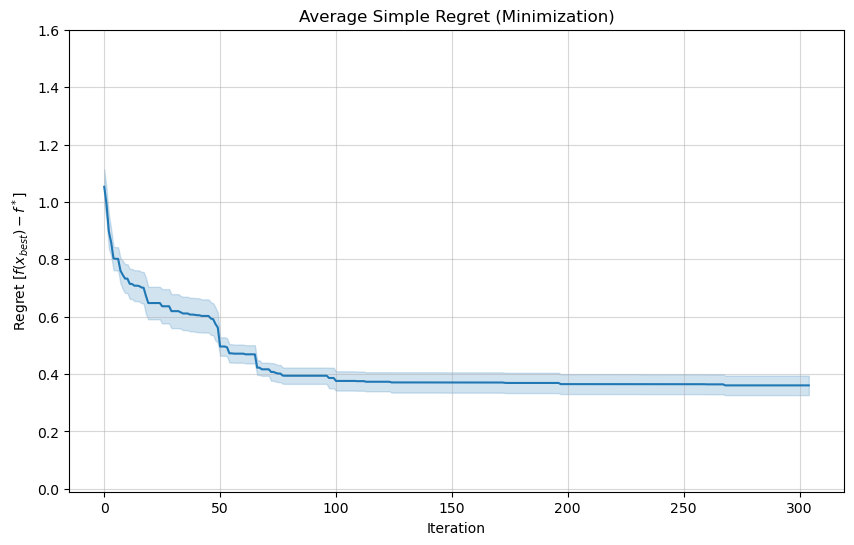

In [144]:
df_regret = dfs_regret[7]
df_regret.index.name = 'Run'
df_plot = df_regret.reset_index().melt(
    id_vars='Run', 
    var_name='Iteration', 
    value_name='Regret'
)

# 4. Plot Mean and Standard Deviation
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='Iteration', y='Regret', errorbar='se')

# plt.yscale('log') # Standard for BO to show convergence
plt.ylim(-0.01,1.6)
plt.title('Average Simple Regret (Minimization)')
plt.ylabel('Regret [$f(x_{best}) - f^*$]')
plt.xlabel('Iteration')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [115]:
y_all[0].cummin(axis=1)

,0,1,2,3,4,5,6,7,8,9,...,295,296,297,298,299,300,301,302,303,304
0,0.585031,0.585031,0.585031,0.585031,0.585031,0.585031,0.585031,0.585031,0.246028,0.246028,...,0.000335,0.000335,0.000335,0.000335,0.000335,0.000335,0.000335,0.000335,0.000335,0.000335
1,1.165161,1.165161,1.165161,0.856787,0.856787,0.856787,0.856787,0.856787,0.856787,0.856787,...,0.003342,0.003342,0.003342,0.003342,0.003342,0.003342,0.003342,0.003342,0.003342,0.003342
2,1.256982,1.256982,0.224168,0.224168,0.224168,0.224168,0.224168,0.202091,0.202091,0.202091,...,0.014849,0.014849,0.014849,0.014849,0.014849,0.014849,0.014849,0.014849,0.014849,0.014849
3,1.469736,0.984824,0.984824,0.984824,0.984824,0.984824,0.984824,0.984824,0.984824,0.984824,...,0.001405,0.001405,0.001405,0.001405,0.001405,0.001405,0.001405,0.001405,0.001405,0.001405
4,1.411724,1.287259,0.289547,0.289547,0.289547,0.289547,0.289547,0.289547,0.289547,0.289547,...,0.013509,0.013509,0.013509,0.013509,0.013509,0.013509,0.013509,0.013509,0.013509,0.013509
5,1.165837,1.165837,1.069210,0.984073,0.984073,0.926689,0.926689,0.926689,0.926689,0.926689,...,0.013384,0.013384,0.013384,0.013384,0.013384,0.013384,0.013384,0.013384,0.013384,0.013384
6,1.318064,1.300864,1.300864,1.300864,1.083419,1.083419,1.083419,0.992134,0.992134,0.992134,...,0.005093,0.005093,0.005093,0.005093,0.005093,0.005093,0.005093,0.005093,0.005093,0.005093
7,0.564433,0.564433,0.564433,0.564433,0.564433,0.564433,0.564433,0.564433,0.432484,0.223715,...,0.001628,0.001628,0.001628,0.001628,0.001628,0.001628,0.001628,0.001628,0.001628,0.001628
8,1.311374,1.110022,1.110022,1.044803,1.044803,1.044803,1.044803,1.044803,1.029737,1.029737,...,0.003060,0.003060,0.003060,0.003060,0.003060,0.003060,0.003060,0.003060,0.003060,0.003060
9,1.328227,1.328227,1.043541,1.043541,0.997030,0.997030,0.997030,0.997030,0.997030,0.997030,...,0.790788,0.790788,0.790788,0.790788,0.790788,0.790788,0.790788,0.790788,0.790788,0.790788


easy_2026-01-13-14-52-23_Synthetic_bo_ts_d_2_p_16_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-17-37_Synthetic_bo_ts_d_2_p_25_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-18-36_Synthetic_bo_ts_d_2_p_4_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-19-29_Synthetic_bo_ts_d_2_p_9_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-20-03_Synthetic_bo_ts_d_3_p_125_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-20-47_Synthetic_bo_ts_d_3_p_27_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-22-02_Synthetic_bo_ts_d_3_p_64_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-23-18_Synthetic_bo_ts_d_3_p_8_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-23-57_Synthetic_bo_ts_d_4_p_16_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-25-29_Synthetic_bo_ts_d_4_p_256_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-26-30_Synthetic_bo_ts_d_4_p_81_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-27-08_Synthetic_bo_ts_d_5_p_243_305_5_1_5_fvgp_1_1_False_auto
easy_2026-01-14-09-29-11_Synthetic_bo_ts

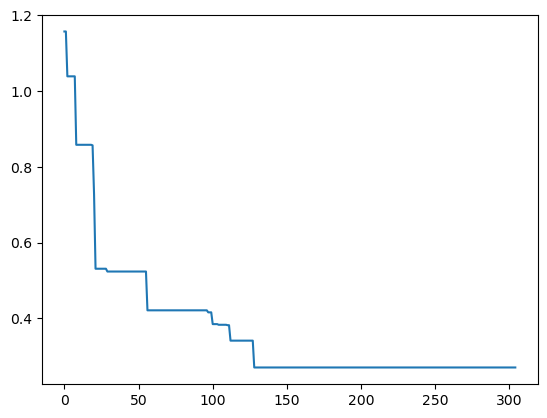

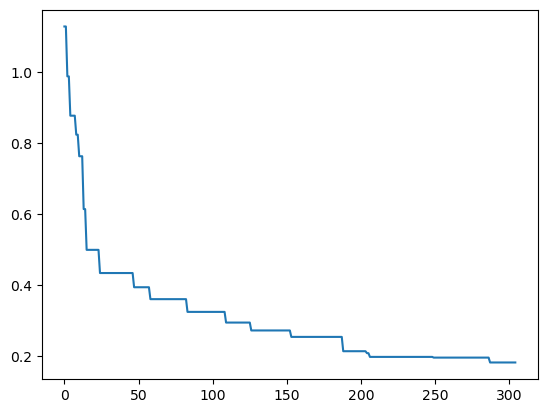

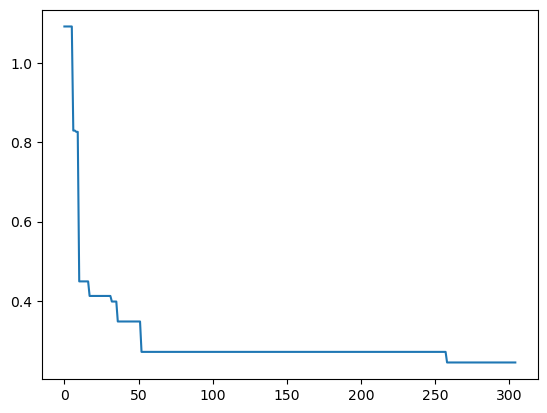

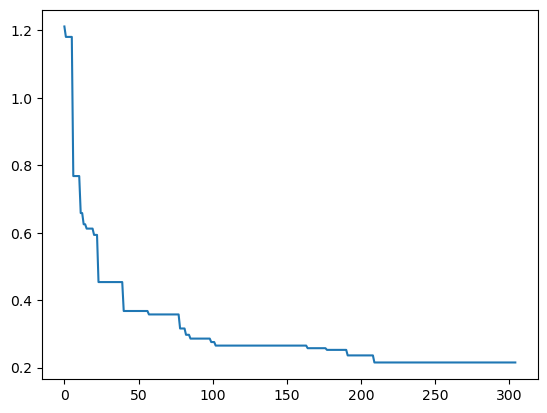

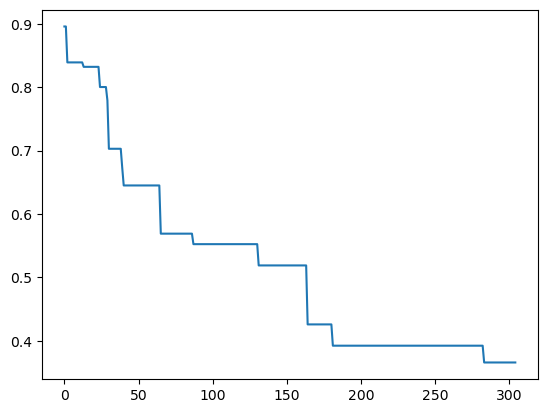

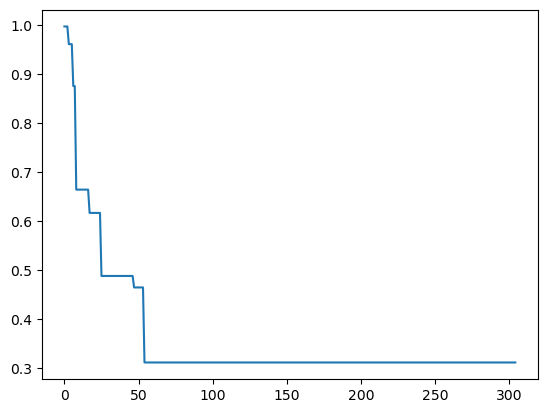

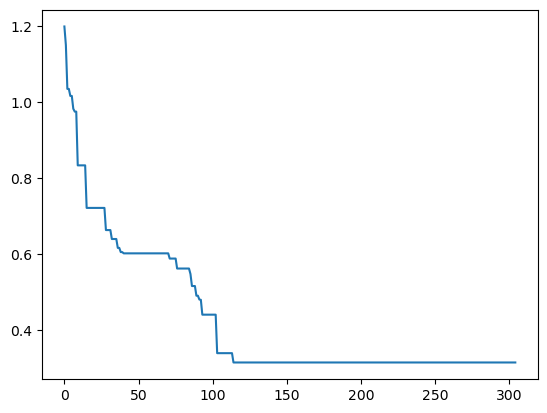

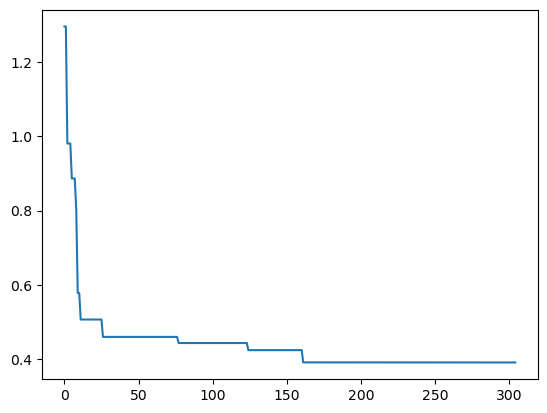

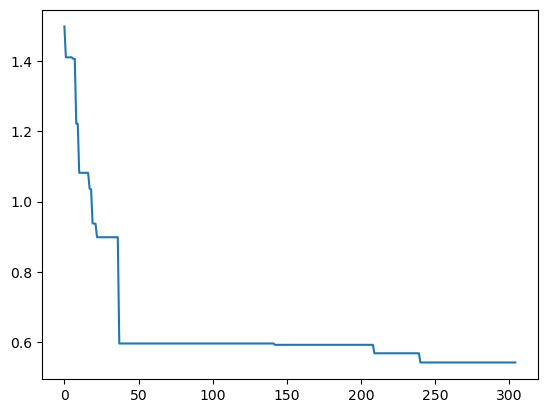

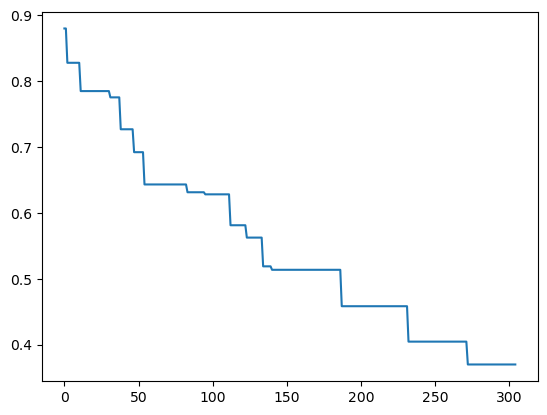

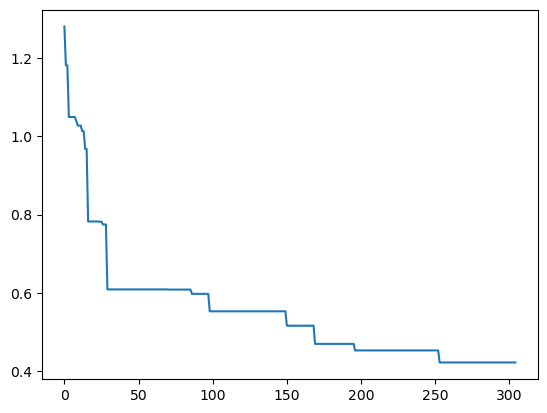

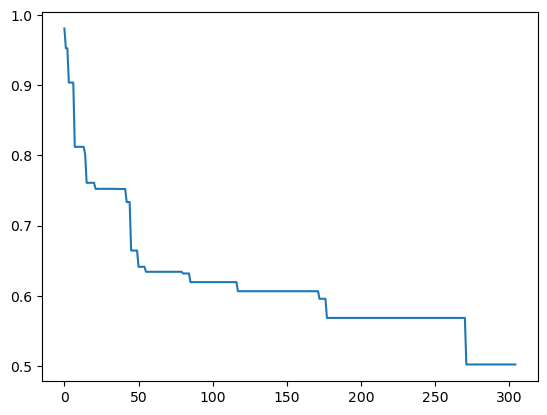

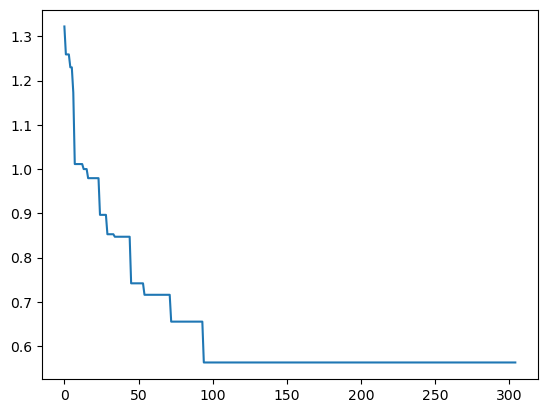

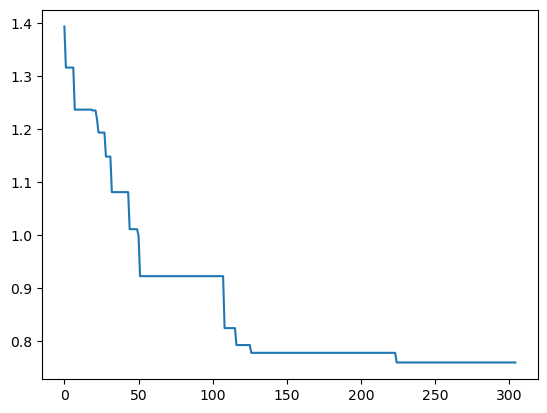

In [112]:
for f_idx in range(len(f)):
    print(f[f_idx])
    mean_y = y_all[f_idx].describe().iloc[1, :]
    simple_regret =  mean_y.cummin()
    plt.figure()
    plt.plot(simple_regret)

In [45]:

rundata = np.load(join(mypath, f[f_idx], files[0]))
rundata.items()

ItemsView(NpzFile '/home/mmalu/cbo_code_011525/FocalBO-main/results/hard/easy_2026-01-14-10-47-14_Synthetic_bo_ts_d_5_p_243_305_5_1_5_fvgp_1_1_False_auto/3.npz' with keys: x, y, best_x, loop_num, max_depth...)

In [46]:
y = rundata['y'].reshape(-1,)

In [47]:
simple_regret = [(min(-1*y[:j+1])) for j in range(305)]

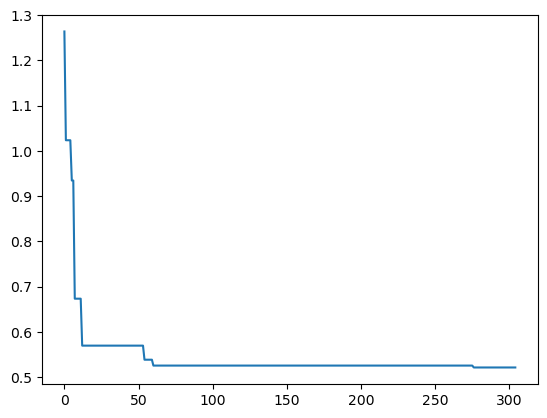

In [48]:
from matplotlib import pyplot as plt
plt.plot(simple_regret)

In [2]:
mypath = '/home/mmalu/cbo_code_011525/exp_baselines/'
onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f))]
onlyfiles.sort()
len(onlyfiles)

1638

In [3]:
strings = ['all_parallel_easy_normalized_alpha_vs_nosupp_base_scaled_noisy_bal_False']
f = []
for i in onlyfiles:
    for j in strings:
        if (i.startswith(j)) and (i.endswith('.pkl')) and ('matern' in i) and ('300_iterations' in i):
            f += [i]

f.sort()
f, len(f)

(['all_parallel_easy_normalized_alpha_vs_nosupp_base_scaled_noisy_bal_False_10d_3dpar_5N_2c_27p_matern_300_iterations10runs_5ensembles_-10leaf_val_1het_1alp-acq_0.01std_090325122033.pkl',
  'all_parallel_easy_normalized_alpha_vs_nosupp_base_scaled_noisy_bal_False_15d_5N_2c_27p_matern_300_iterations10runs_5ensembles_-10leaf_val_1het_1alp-acq_0.01std_090225193308.pkl',
  'all_parallel_easy_normalized_alpha_vs_nosupp_base_scaled_noisy_bal_False_20d_3dpar_5N_2c_27p_matern_300_iterations10runs_5ensembles_-10leaf_val_1het_1alp-acq_0.01std_090325132143.pkl',
  'all_parallel_easy_normalized_alpha_vs_nosupp_base_scaled_noisy_bal_False_25d_3dpar_5N_2c_27p_matern_300_iterations10runs_5ensembles_-10leaf_val_1het_1alp-acq_0.01std_090325130900.pkl',
  'all_parallel_easy_normalized_alpha_vs_nosupp_base_scaled_noisy_bal_False_30d_3dpar_5N_2c_27p_matern_300_iterations10runs_5ensembles_-10leaf_val_1het_1alp-acq_0.01std_090325130515.pkl',
  'all_parallel_easy_normalized_alpha_vs_nosupp_base_scaled_noisy_

In [4]:
i = 0
data = pkl.load(open(join(mypath,f[i]), 'rb'))
data['params']

{'alpha_acq': 1,
 'freq': array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]),
 'alpha_fun': 10,
 'beta_fun': 0,
 'const_fun': array([[-2.3],
        [-0.5],
        [-0.7],
        [-0.8],
        [-4.7],
        [-1.1],
        [-2.1],
        [-2. ],
        [-1.2],
        [-2.6],
        [-0.4],
        [-0.3],
        [-1.6],
        [-1.4],
        [-1.8],
        [-0.9],
        [-1.5],
        [-2.2],
        [-0. ],
        [-0.1],
        [-1. ],
        [-1.9],
        [-1.7],
        [-0.6],
        [-2.5],
        [-7.7],
        [-1.3]]),
 'tol': 0.5,
 'n_trials': 10,
 'emt_llh': -70,
 'samp_fit': 1,
 'obj_bnds': [(-10, 10),
  (-10, 10),
  (-10, 10),
  (-10, 10),
  (-10, 10),
  (-10, 10),
  (-10, 10),
  (-10, 10),
  (-10, 10),
  (-10, 10)],
 'obj_func': <function cbo_fin_datagen_v1.scaled_gen_ydataset_min(X, C, P, partitions, partition_mat, freq, const, alpha=10, std=0)>,
 'kernel': 1**2 * Matern(length_scale=[1, 1, 1, 1, 1

### Initialization of the test function

In [5]:
# rstate = 123  # Random State 123,130,175,
# prng = RandomState(rstate)
dim = data['params']['d']
bnds = data['params']['obj_bnds']
minimize = False
balanced = data['params']['balanced']
k = data['params']['k']
tup = data['params']['tup']
partition = data['params']['p']
std = data['params']['std']
alpha = data['params']['alpha_fun']
if balanced:
    partitions, label_mat = gen_checker_partitions(dim, k, tup, bnds)
else:
    partitions, label_mat = gen_checker_par_unbalanced1(dim, k, tup, bnds)
partition_mat = np.arange(partition).reshape(tup)
const = data['params']['const_fun']

### Initialization for Focal BO

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
dtype = torch.float
torch.manual_seed(0)
gp_model = 'fvgp'
max_loop_num = 1
init = False
# algo = 'turbo'
algo = 'bo'
acqf = 'ts'
# Problem settings
n_initial_samples = 5 # number of initial random samples
# additional_evals = 290  # the number of evaluations after the initial random samples
# n_samples_per_step = 10  # number of new samples per step
# induce_size=20
n_evals = data['params']['T']  # number of optimization steps
n_repeat = 1
n_samples_per_step = 1  # number of new samples per step
induce_size = 5
f_objective = 'func'
use_depth = 1
auto = 1

cuda


In [7]:
# Define the objective function (the Branin function)
if f_objective == 'func':
    bounds = torch.cat((-10*torch.ones(1, dim), 10*torch.ones(1, dim))).to(dtype=dtype, device=device) # bounds of the problem
    objective = Synthetic(dim=dim, minimize=minimize, balanced=balanced,
                           k=k, tup=tup, partition=partition, std=std, 
                           partition_mat=partition_mat, label_mat=label_mat, 
                           partitions=partitions, const=const, alpha=alpha)
    print(bounds)

    
def eval_objective(x):
    # print(x.shape)
    unnorm_x = unnormalize(x, bounds)
    ndim = len(x.shape)
    if ndim == 3:
        y = torch.zeros(x.shape[0], x.shape[1], 1).to(dtype=dtype, device=device)
        for i in range(x.shape[0]):
            for j in range(x.shape[1]):
                y[i, j] = objective(unnorm_x[i, j])
                print(i, j, y[i, j], end='\r')
    else:
        y = torch.zeros(x.shape[0], 1).to(dtype=dtype, device=device)
        for i in range(x.shape[0]):
            y_int = objective(unnorm_x[i])
            # print(y_int)
            y[i] = y_int[0]
        print(i, y[i], end='\r')
    print('')
    return y

tensor([[-10., -10., -10., -10., -10., -10., -10., -10., -10., -10.],
        [ 10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.]],
       device='cuda:0')


In [9]:
cur_time = time.strftime('%Y-%m-%d-%H-%M-%S', time.localtime(time.time()))
if not isinstance(objective, SyntheticTestFunction):
    obj_name = objective.name
    save_path = f'results/easy_{cur_time}_{objective.name}_{algo}_{acqf}_d_{dim}_p_{partition}_{n_evals}_{n_initial_samples}_{n_samples_per_step}_{induce_size}_{gp_model}_{use_depth}'
else:
    obj_name = objective.__class__.__name__
    save_path = f'results/easy_{cur_time}_{objective.__class__.__name__}_{algo}_{acqf}_d_{dim}_p_{partition}_{n_evals}_{n_initial_samples}_{n_samples_per_step}_{induce_size}_{gp_model}_{use_depth}'
# if gp_model == 'fvgp':
save_path += f'_{max_loop_num}_{init}'
# if gp_model == 'fvgp':
auto_suffix = '_auto' if auto == 1 else ''
save_path += auto_suffix
print(save_path)

results/easy_2026-01-07-10-03-42_Synthetic_bo_ts_d_10_300_5_1_5_fvgp_1_1_False_auto


In [10]:
from joblib import Parallel, delayed

In [20]:
def single_run(run_id):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dtype = torch.float
    gp_model = 'fvgp'
    max_loop_num = 1
    init = False
    algo = 'bo'
    acqf = 'ts'
    n_initial_samples = 5 # number of initial random samples
    n_evals = data['params']['T']  # number of optimization steps
    n_samples_per_step = 1  # number of new samples per step
    induce_size = 5
    use_depth = 1
    auto = 1
    rep = run_id
    print(f"\n+++++++++++++++++ Starting Run {run_id + 1}/{runs} ++++++++++++++++++++++++")
    unnorm_initial_X = torch.from_numpy(data[run_id]['X']).to(dtype=dtype, device=device)
    initial_X = normalize(unnorm_initial_X, bounds)
    initial_Y = -1*torch.from_numpy(data[run_id]['Y'].reshape(-1, 1)).to(dtype=dtype, device=device)
    with gpytorch.settings.max_cholesky_size(float('inf')):
        start_time = time.time()
        model = likelihood = None
        max_loop_num = max_loop_num
        
        if not isinstance(objective, SyntheticTestFunction):
            train_X = initial_X[:n_initial_samples].clone()
            train_Y = initial_Y[:n_initial_samples].clone()
        best_observed_value_index = train_Y.argmax()

        state = TurboState(dim, batch_size=n_samples_per_step, length=1)
        try:
            print(f"{obj_name} {rep} Init {len(train_X)} Best regret: {objective.optimal_value - train_Y[best_observed_value_index]}")
        except:
            print(f"{obj_name} {rep} Init {len(train_X)} Best reward: {train_Y[best_observed_value_index]}")
            
        all_loop_nums = []
        all_max_depth = []
        all_depth_record = torch.zeros(0, 1).to(dtype=dtype, device=device)
        while len(train_X) < n_evals:
            print(f'=====Start optimization round with {len(train_X)} samples=====')
            norm_Y = (train_Y-train_Y.mean())/train_Y.std()
            norm_Y = norm_Y.ravel()
            train_dataset = TensorDataset(train_X, norm_Y)
            # train_dataset = TensorDataset(train_X, train_Y)
            train_loader = DataLoader(train_dataset, batch_size=30000, shuffle=True)
            x_center = 0.5 * torch.ones(1, dim).to(dtype=dtype, device=device) # center of the input region
                
            if gp_model == 'gp' or len(train_X) < induce_size:
                model, likelihood = train_gp(train_X, norm_Y, num_epochs=num_epochs)
                tr = cand_tr =  torch.cat((torch.zeros(dim).reshape(1, -1), torch.ones(dim).reshape(1, -1))).to(dtype=dtype, device=device)
                # model = train_gp(train_X, train_Y, num_epochs=num_epochs)
            else:
                if gp_model == 'fvgp':
                    try:
                        base_length = state.length
                        in_center_num = 0
                        increase_step = 0.01
                        tr =  torch.cat((torch.zeros(dim).reshape(1, -1), torch.ones(dim).reshape(1, -1))).to(dtype=dtype, device=device)
                        cand_tr = tr
                        # print(tr)
                    except Exception as e:
                        print('error', e)
                        # tr = torch.cat((torch.zeros(1, dim), torch.ones(1, dim))).to(dtype=dtype, device=device)
                        raise NotImplementedError
                    
                    model, likelihood = train_fvgp(train_loader, tr, num_epochs=num_epochs, induce_size=induce_size, 
                                                    init=init)
            # Define the acquisition function
            if gp_model == 'fvgp' or use_depth == 1: # sparse to dense optimization for fvgp and vanilla BO
                train_new_gp = True if gp_model == 'fvgp' else False
                new_X, new_depth = focal_acqf_opt_sample(model, likelihood, deepcopy(state), x_center, acqf, 
                                        train_loader, num_epochs=num_epochs, 
                                        max_loop_num=max_loop_num, batch_size=n_samples_per_step, init=init, tr=tr, cand_tr=cand_tr, train_new_gp=train_new_gp)
                # print('x next', new_X)
                depth_num = []
                for l_idx in range(max_loop_num):
                    depth_num.append((new_depth == l_idx).sum().item())
                print(f'Batch number of each depth {depth_num}')
                all_depth_record = torch.cat((all_depth_record, new_depth), 0)
            
            # Update the training data, make sure to convert back to cuda bc of vecchia
            # Evaluate the objective function at the new samples
            device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            train_X, train_Y, norm_Y = train_X.to(device=device), train_Y.to(device=device), norm_Y.to(device=device), 
            
            new_Y = eval_objective(new_X.to(device=device)).reshape(-1, 1)
            
            train_X = torch.cat([train_X, new_X.to(device=device)])
            train_Y = torch.cat([train_Y, new_Y.to(device=device)])
            
            # Print the location of the best observed value
            best_observed_value_index = train_Y.argmax()
            try:
                print(f'{obj_name} {gp_model} {algo} {rep} Eval {len(train_X)}'\
                    f'Best this round: {objective.optimal_value - new_Y.max()} '\
                    f'Best regret: {objective.optimal_value - train_Y[best_observed_value_index]}')\
                
            except:
                print(f'{obj_name} {gp_model} {algo} {rep} Eval {len(train_X)}'\
                    f'Best this round: {new_Y.max()} '\
                    f'Best reward: {train_Y[best_observed_value_index]}')
                
            if gp_model == 'fvgp' or use_depth ==1 and len(train_X) >= induce_size:
                budget_per_loop = []
                total_budget = n_samples_per_step
                n_per_loop = int(np.ceil(n_samples_per_step/max_loop_num))
                val_per_depth = []
                
                for i in range(max_loop_num):
                    b = min(n_per_loop, total_budget)
                    budget_per_loop.append(b)
                    total_budget -= b
                
                budget_per_loop.reverse()
                start = 0
                for b in budget_per_loop:
                    val_per_depth.append(new_Y[start:start+b].mean())
                    start += b
                
                # check the best depth
                max_idx = new_Y.argmax()
                
                depth = new_depth[max_idx].item()  
                if auto == 1:
                    if depth + 1 < max_loop_num:
                        max_loop_num -= 1
                    else:
                        # max_loop_num = min(dim, max_loop_num+1)
                        max_loop_num += 1
                    # max_loop_num = depth + 1
                print(f'Max point find in depth {depth+1}, set max loop num to {max_loop_num}')
                
                    
                all_loop_nums.append(max_loop_num)
                all_max_depth.append(depth+1)
                
            # if not os.path.exists(save_path):
            #     os.mkdir(save_path)
            if dim < 3:
                np.savez(f'{save_path}_{run_id}.npz', x=train_X.detach().cpu().numpy(), 
                            y=train_Y.detach().cpu().numpy(), loop_num=np.array(all_loop_nums), 
                            max_depth=np.array(all_max_depth), depth_record=all_depth_record.detach().cpu().numpy())
            else:
                best_x = train_X[best_observed_value_index].detach().cpu().numpy()
                np.savez(f'{save_path}_{run_id}.npz', y=train_Y.detach().cpu().numpy(), 
                            best_x=best_x, loop_num=np.array(all_loop_nums), 
                            max_depth=np.array(all_max_depth), depth_record=all_depth_record.detach().cpu().numpy())
        print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
num_epochs = 200
n_jobs = 10
runs = 10

Parallel(n_jobs=n_jobs)(delayed(single_run)(i) for i in range(runs))


+++++++++++++++++ Starting Run 2/10 ++++++++++++++++++++++++
Synthetic 1 Init 5 Best reward: tensor([-1.1130], device='cuda:0')
=====Start optimization round with 5 samples=====
in region points 5
induce bound tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
tensor(0.9732, device='cuda:0') tensor(0.0692, device='cuda:0')
64 5 1.432527780532837 1.432527780532837 1.432527780532837 0.69881063699722299 0.0 6.20359 3.43873 0.86013 0 1.0 1.0.00.73849 0 1.0 1.0
+++++++++++++++++ Starting Run 1/10 ++++++++++++++++++++++++
Synthetic 0 Init 5 Best reward: tensor([-1.4057], device='cuda:0')
=====Start optimization round with 5 samples=====
in region points 5
induce bound tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], 

In [23]:
# n_repeat = 10
run_idx = 0
num_epochs = 200
n_evals = 50

unnorm_initial_X = torch.from_numpy(data[run_idx]['X']).to(dtype=dtype, device=device)
initial_X = normalize(unnorm_initial_X, bounds)
initial_Y = -1*torch.from_numpy(data[run_idx]['Y'].reshape(-1, 1)).to(dtype=dtype, device=device)
print(initial_X.shape, initial_Y.shape, initial_Y.max(0), initial_Y.argmax(0))

# gen_ini = True

# if gen_ini:
#     sobol = SobolEngine(dim, scramble=True)
#     initial_X = sobol.draw(n_initial_samples).to(dtype=dtype, device=device)
#     initial_Y = eval_objective(initial_X).reshape(-1, 1).to(dtype=dtype, device=device)
#     print(initial_Y.shape, initial_Y.max(0), initial_Y.argmax(0))
    
    # # raise NotImplementedError
    # # torch.seed()
    # # if isinstance(objective, mujoco_gym_env.MujocoGymEnv) or isinstance(objective, lunar_land.Lunar):
    # if not isinstance(objective, SyntheticTestFunction):
    #     with open(f'./initial_data/{objective.__name__}', 'wb') as file: 
    #         # A new file will be created 
    #         all_var = (initial_X, initial_Y)
    #         pkl.dump(all_var, file) 

torch.Size([5, 10]) torch.Size([5, 1]) torch.return_types.max(
values=tensor([-1.4057], device='cuda:0'),
indices=tensor([4], device='cuda:0')) tensor([4], device='cuda:0')


In [24]:
initial_Y

tensor([[-2.3984],
        [-1.5448],
        [-2.6397],
        [-1.4264],
        [-1.4057]], device='cuda:0')

In [25]:
with gpytorch.settings.max_cholesky_size(float('inf')):
    for rep in range(n_repeat):
        start_time = time.time()
        model = likelihood = None
        max_loop_num = max_loop_num
        if not isinstance(objective, SyntheticTestFunction):
            train_X = initial_X[:n_initial_samples].clone()
            train_Y = initial_Y[:n_initial_samples].clone()
            # clear cache when using GP function
            if isinstance(objective, GPFunction):
                del objective
                objective = GPFunction(dim=dim, ls=0.2)
                objective.eval_x = train_X
                objective.eval_y = train_Y.ravel()
        best_observed_value_index = train_Y.argmax()

        if algo == 'turbo':
            state = TurboState(dim, batch_size=n_samples_per_step)
            try:
                print(f"{obj_name} {rep} Init {len(train_X)} {state.length} Best regret: {objective.optimal_value - train_Y[best_observed_value_index]}")
            except:
                print(f"{obj_name} {rep} Init {len(train_X)} {state.length} Best reward: {train_Y[best_observed_value_index]}")

        else:
            state = TurboState(dim, batch_size=n_samples_per_step, length=1)
            # state = TurboState(dim, batch_size=n_samples_per_step, length=1)
            try:
                print(f"{obj_name} {rep} Init {len(train_X)} Best regret: {objective.optimal_value - train_Y[best_observed_value_index]}")
            except:
                print(f"{obj_name} {rep} Init {len(train_X)} Best reward: {train_Y[best_observed_value_index]}")
        all_loop_nums = []
        all_max_depth = []
        all_depth_record = torch.zeros(0, 1).to(dtype=dtype, device=device)
        while len(train_X) < n_evals:
            print(f'=====Start optimization round with {len(train_X)} samples=====')
            norm_Y = (train_Y-train_Y.mean())/train_Y.std()
            norm_Y = norm_Y.ravel()
            train_dataset = TensorDataset(train_X, norm_Y)
            # train_dataset = TensorDataset(train_X, train_Y)
            train_loader = DataLoader(train_dataset, batch_size=30000, shuffle=True)
            if algo == 'turbo':
                x_center = train_X[norm_Y.argmax()]
            else:
                x_center = 0.5 * torch.ones(1, dim).to(dtype=dtype, device=device) # center of the input region
                
            if gp_model == 'gp' or len(train_X) < induce_size:
                model, likelihood = train_gp(train_X, norm_Y, num_epochs=num_epochs)
                tr = cand_tr =  torch.cat((torch.zeros(dim).reshape(1, -1), torch.ones(dim).reshape(1, -1))).to(dtype=dtype, device=device)
                # model = train_gp(train_X, train_Y, num_epochs=num_epochs)
            else:
                if gp_model == 'fvgp':
                    try:
                        base_length = state.length
                        in_center_num = 0
                        increase_step = 0.01
                        if algo == 'turbo':
                            # try:
                            #     weights = model.covar_module.base_kernel.lengthscale.squeeze().detach()
                            #     weights = weights / weights.mean()
                            #     weights = weights / torch.prod(weights.pow(1.0 / len(weights)))
                            # except:
                            weights = torch.ones(dim).to(dtype=dtype, device=device)
                            print('origin tr weights', weights.mean(), weights.std(), weights.max(), weights.min())
                            tr_lb = torch.clamp(x_center - weights*base_length / 2.0, 0.0, 1.0)
                            tr_ub = torch.clamp(x_center + weights*base_length / 2.0, 0.0, 1.0)
                            tr = cand_tr = torch.cat((tr_lb.reshape(1, -1), tr_ub.reshape(1, -1))).to(dtype=dtype, device=device)
                            lb = tr_lb.expand(len(train_X), len(tr_lb.ravel()))
                            ub = tr_ub.expand(len(train_X), len(tr_ub.ravel()))
                            clamp_x = torch.clamp(train_X, lb, ub)
                            diff = (torch.abs(train_X-clamp_x)).sum(-1)
                            in_center_num = len(diff[diff==0])
                            # while(in_center_num < induce_size):
                            #     tr_lb = torch.clamp(x_center - weights*base_length / 2.0, 0.0, 1.0)
                            #     tr_ub = torch.clamp(x_center + weights*base_length / 2.0, 0.0, 1.0)
                            #     lb = tr_lb.expand(len(train_X), len(tr_lb.ravel()))
                            #     ub = tr_ub.expand(len(train_X), len(tr_ub.ravel()))
                            #     clamp_x = torch.clamp(train_X, lb, ub)
                            #     diff = (torch.abs(train_X-clamp_x)).sum(-1)
                            #     in_center_num = len(diff[diff==0])
                            #     base_length += increase_step
                            
                            print('in center', in_center_num, base_length)
                            tr = torch.cat((tr_lb.reshape(1, -1), tr_ub.reshape(1, -1))).to(dtype=dtype, device=device)
                        else:
                            tr =  torch.cat((torch.zeros(dim).reshape(1, -1), torch.ones(dim).reshape(1, -1))).to(dtype=dtype, device=device)
                            cand_tr = tr
                        # print(tr)
                    except Exception as e:
                        print('error', e)
                        # tr = torch.cat((torch.zeros(1, dim), torch.ones(1, dim))).to(dtype=dtype, device=device)
                        raise NotImplementedError
                    
                    model, likelihood = train_fvgp(train_loader, tr, num_epochs=num_epochs, induce_size=induce_size, 
                                                    init=init)
            # Define the acquisition function
            if gp_model == 'fvgp' or use_depth == 1: # sparse to dense optimization for fvgp and vanilla BO
                train_new_gp = True if gp_model == 'fvgp' else False
                new_X, new_depth = focal_acqf_opt_sample(model, likelihood, deepcopy(state), x_center, acqf, 
                                        train_loader, num_epochs=num_epochs, 
                                        max_loop_num=max_loop_num, batch_size=n_samples_per_step, init=init, tr=tr, cand_tr=cand_tr, train_new_gp=train_new_gp)
                # print('x next', new_X)
                depth_num = []
                for l_idx in range(max_loop_num):
                    depth_num.append((new_depth == l_idx).sum().item())
                print(f'Batch number of each depth {depth_num}')
                all_depth_record = torch.cat((all_depth_record, new_depth), 0)
            
            # Update the training data, make sure to convert back to cuda bc of vecchia
            # Evaluate the objective function at the new samples
            device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            train_X, train_Y, norm_Y = train_X.to(device=device), train_Y.to(device=device), norm_Y.to(device=device), 
            
            new_Y = eval_objective(new_X.to(device=device)).reshape(-1, 1)
            
            train_X = torch.cat([train_X, new_X.to(device=device)])
            train_Y = torch.cat([train_Y, new_Y.to(device=device)])
            
            # Print the location of the best observed value
            best_observed_value_index = train_Y.argmax()
            try:
                print(f'{obj_name} {gp_model} {algo} {rep} Eval {len(train_X)}'\
                    f'Best this round: {objective.optimal_value - new_Y.max()} '\
                    f'Best regret: {objective.optimal_value - train_Y[best_observed_value_index]}')\
                
            except:
                print(f'{obj_name} {gp_model} {algo} {rep} Eval {len(train_X)}'\
                    f'Best this round: {new_Y.max()} '\
                    f'Best reward: {train_Y[best_observed_value_index]}')
                
            if gp_model == 'fvgp' or use_depth ==1 and len(train_X) >= induce_size:
                budget_per_loop = []
                total_budget = n_samples_per_step
                n_per_loop = int(np.ceil(n_samples_per_step/max_loop_num))
                val_per_depth = []
                
                for i in range(max_loop_num):
                    b = min(n_per_loop, total_budget)
                    budget_per_loop.append(b)
                    total_budget -= b
                
                budget_per_loop.reverse()
                start = 0
                for b in budget_per_loop:
                    val_per_depth.append(new_Y[start:start+b].mean())
                    start += b
                
                # check the best depth
                max_idx = new_Y.argmax()
                
                    
                depth = new_depth[max_idx].item()  
                # for depth in range(max_loop_num):
                #     if max_idx < np.sum(budget_per_loop[:depth+1]):
                #         break
                # if new_Y.max() == train_Y.max():
                if auto == 1:
                    if depth + 1 < max_loop_num:
                        max_loop_num -= 1
                    else:
                        # max_loop_num = min(dim, max_loop_num+1)
                        max_loop_num += 1
                    # max_loop_num = depth + 1
                print(f'Max point find in depth {depth+1}, set max loop num to {max_loop_num}')
                # else:
                #     max_loop_num += 1
                #     print(f'Not find max {depth+1} {val_per_depth}, increase max loop num to {max_loop_num}')
                
                    
                all_loop_nums.append(max_loop_num)
                all_max_depth.append(depth+1)
                
                # print(f'Max point find in depth {depth+1} {val_per_depth}, set max loop num to {max_loop_num}')
                # else:
                #     print(f'Max point find in depth {depth+1} {val_per_depth}, current max loop num to {max_loop_num}')
                
            if not os.path.exists(save_path):
                os.mkdir(save_path)
            if dim < 3:
                np.savez(f'{save_path}/{run_idx}.npz', x=train_X.detach().cpu().numpy(), 
                            y=train_Y.detach().cpu().numpy(), loop_num=np.array(all_loop_nums), 
                            max_depth=np.array(all_max_depth), depth_record=all_depth_record.detach().cpu().numpy())
            else:
                best_x = train_X[best_observed_value_index].detach().cpu().numpy()
                np.savez(f'{save_path}/{run_idx}.npz', y=train_Y.detach().cpu().numpy(), 
                            best_x=best_x, loop_num=np.array(all_loop_nums), 
                            max_depth=np.array(all_max_depth), depth_record=all_depth_record.detach().cpu().numpy())
        print("--- %s seconds ---" % (time.time() - start_time))

Synthetic 0 Init 5 Best reward: tensor([-1.4057], device='cuda:0')
=====Start optimization round with 5 samples=====
in region points 5
induce bound tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
tensor(0.9714, device='cuda:0') tensor(0.0136, device='cuda:0')
199 5 1.407382845878601 1.407382845878601 1.407382845878601 0.7936668992042542 0.0 7.79147 4.57129 0.91878 0 1.0 1.01.00.92214 0 1.0 1.0.0
model ls 6.508094310760498 1.1394459009170532 7.79147481918335 4.571285247802734
start center tensor(0.5000, device='cuda:0') tensor(0.5000, device='cuda:0') tensor(0.5000, device='cuda:0') 1
gp tr tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], device='cuda:0')
cand tr tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1

In [ ]:
max(train_Y), min(train_Y)

In [17]:
rundata = np.load('results/easy_2026-01-06-23-26-00_Synthetic_bo_ts_d_10_300_5_1_5_fvgp_1_1_False_auto/0.npz')

In [20]:
rundata.items()

ItemsView(NpzFile 'results/easy_2026-01-06-23-26-00_Synthetic_bo_ts_d_10_300_5_1_5_fvgp_1_1_False_auto/0.npz' with keys: y, best_x, loop_num, max_depth, depth_record)

In [21]:
print(rundata.files)

['y', 'best_x', 'loop_num', 'max_depth', 'depth_record']


In [26]:
const

array([[-2.3],
       [-0.5],
       [-0.7],
       [-0.8],
       [-4.7],
       [-1.1],
       [-2.1],
       [-2. ],
       [-1.2],
       [-2.6],
       [-0.4],
       [-0.3],
       [-1.6],
       [-1.4],
       [-1.8],
       [-0.9],
       [-1.5],
       [-2.2],
       [-0. ],
       [-0.1],
       [-1. ],
       [-1.9],
       [-1.7],
       [-0.6],
       [-2.5],
       [-7.7],
       [-1.3]])

In [25]:
rundata['best_x']

array([0.09497, 0.42341, 0.21436, 0.75066, 0.01526, 0.81141, 0.31816,
       0.4517 , 0.48756, 0.88896], dtype=float32)

In [23]:
y_out = rundata['y']

In [24]:
max(y_out), min(y_out)

(array([-1.10787], dtype=float32), array([-3.03509], dtype=float32))

In [16]:
!pwd

/home/mmalu/cbo_code_011525/FocalBO-main


In [ ]:
parser = argparse.ArgumentParser(description='BO experiment')
parser.add_argument('--model', default='fvgp', type=str, help='GP model name')
parser.add_argument('--algo', default='bo', type=str, help='BO optimizer name')
parser.add_argument('--acqf', default='ts', type=str, help='BO acquisition function name')
parser.add_argument('--induce_size', default=20, type=int, help='Induce size of sparse GP')
parser.add_argument('--max_loop_num', default=1, type=int, help='Optimization depth for Focal BO')
parser.add_argument('--use_depth', default=0, type=int, help='1 for use in-depth optimization 0 for not use')
parser.add_argument('--round', default=10, type=int, help='Round of optimization')
parser.add_argument('--init_num', default=20, type=int, help='Initial point number of each round')
parser.add_argument('--eval_num', default=300, type=int, help='Evaluation number of each round')
parser.add_argument('--batch_size', default=10, type=int, help='Batch size of each iteration')
parser.add_argument('--auto', default=1, type=int, help='whether adaptivaly adjust the depth')
parser.add_argument('--task', default='Ackley', type=str, help='Optimization task name')
args = parser.parse_args()

if __name__ == '__main__':
    # mp.set_start_method('spawn', force=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dtype = torch.float
    torch.manual_seed(0)
    gp_model = args.model
    # gp_model = 'fvgp'
    max_loop_num = args.max_loop_num
    # gp_model = 'svgp'
    init = False
    # algo = 'turbo'
    algo = args.algo
    acqf = args.acqf
    # Problem settings
    n_initial_samples = args.init_num # number of initial random samples
    # additional_evals = 290  # the number of evaluations after the initial random samples
    # n_samples_per_step = 10  # number of new samples per step
    # induce_size=20
    n_evals = args.eval_num  # number of optimization steps
    n_repeat = args.round
    n_samples_per_step = args.batch_size  # number of new samples per step
    induce_size = args.induce_size
    # additional_evals = 19000  # the number of evaluations after the initial random samples
    # n_samples_per_step = 200  # number of new samples per step
    # induce_size=1000
    print(args.task)

In [7]:
from matplotlib import pyplot as plt
from matplotlib import cm

def cnt_plt(a1, a2, value, n, title):
    """ Contour plots for 2D input space """
    fig, ax = plt.subplots()
    h = ax.contourf(a1, a2, value.reshape(len(a1), len(a2)), n)
    cbar = plt.colorbar(h)
    cbar.ax.set_ylabel('y')
    ax.set_title(title)
    ax.set_ylabel('x2')
    ax.set_xlabel('x1')
    plt.show()


def surf_plt(a1, a2, value, title):
    """ Surface plots for 2D input space """
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    surf = ax.plot_surface(a1, a2, value.reshape(len(a1), len(a2)), cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('Evaluations')
    ax.set_title(title)
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

In [8]:
n = 100
Xtra = np.linspace(0, 1, n).reshape(-1,1) # Range along each coordinate
Ztra = np.linspace(0, 1, n).reshape(-1,1) # Range along each coordinate

x1,z1 = np.meshgrid(Xtra,Ztra) # Coordinates for each point in the grid where x1 is 1st and z1 is 2nd

x = x1.reshape(-1,1) # Reshaping the coordinates
z = z1.reshape(-1,1) # Reshaping the coordinates

Xplt = np.hstack((x,z)) # Coordinates stacked

In [9]:
Yplt = eval_objective(torch.tensor(Xplt, dtype=dtype, device=device)) # Evaluating the function at each coordinate

9999 tensor([-1.0810], device='cuda:0')


In [10]:
Yplt_np = np.array(Yplt.detach().cpu())
Yplt_np

/tmp/ipykernel_3326247/3947513260.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Yplt_np = np.array(Yplt.detach().cpu())


array([[-1.4655638],
       [-1.4080753],
       [-1.4053489],
       ...,
       [-1.0577554],
       [-1.0545262],
       [-1.0810161]], shape=(10000, 1), dtype=float32)

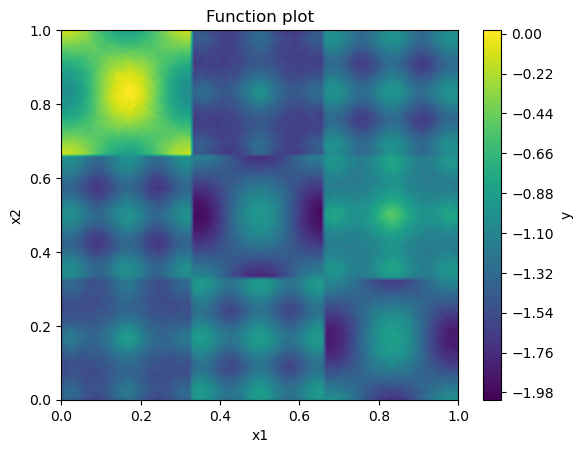

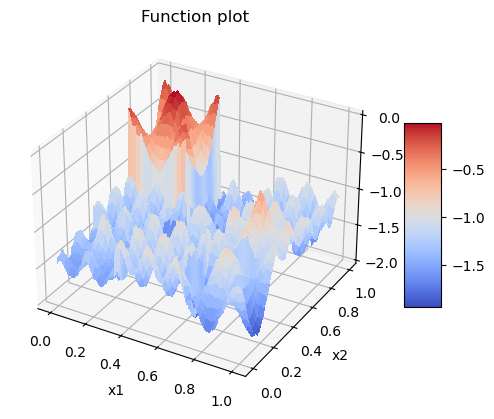

In [11]:
cnt_plt(x1,z1,Yplt_np,100,"Function plot")
surf_plt(x1,z1,Yplt_np,"Function plot")